## Regresión Ponderada Geográficamente (GWR)

In [1]:
# librerias
import libpysal as ps
import numpy
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn
import numpy as np
from mgwr.gwr import GWR
from mgwr.sel_bw import Sel_BW
from shapely.geometry import Point

In [2]:
df = gpd.read_file('../data/regresion_POMCA_Final.geojson')
df.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 293 entries, 0 to 292
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   HYBAS_ID           293 non-null    int64   
 1   MAIN_BAS           293 non-null    int64   
 2   num_species        293 non-null    int32   
 3   num_points         293 non-null    int32   
 4   bio1_mean          293 non-null    float64 
 5   bio3_mean          293 non-null    float64 
 6   bio4_mean          293 non-null    float64 
 7   bio7_mean          293 non-null    float64 
 8   bio12_mean         293 non-null    float64 
 9   bio15_mean         293 non-null    float64 
 10  elevacion          293 non-null    float64 
 11  sp_density         293 non-null    float64 
 12  num_species_std    293 non-null    float64 
 13  w_num_species_std  293 non-null    float64 
 14  num_points_std     293 non-null    float64 
 15  w_num_points_std   293 non-null    float64 
 16  

In [3]:
df['HYBAS_ID'] = df['HYBAS_ID'].astype(str)
df = df.drop(columns=['MAIN_BAS'])
df.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 293 entries, 0 to 292
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   HYBAS_ID           293 non-null    object  
 1   num_species        293 non-null    int32   
 2   num_points         293 non-null    int32   
 3   bio1_mean          293 non-null    float64 
 4   bio3_mean          293 non-null    float64 
 5   bio4_mean          293 non-null    float64 
 6   bio7_mean          293 non-null    float64 
 7   bio12_mean         293 non-null    float64 
 8   bio15_mean         293 non-null    float64 
 9   elevacion          293 non-null    float64 
 10  sp_density         293 non-null    float64 
 11  num_species_std    293 non-null    float64 
 12  w_num_species_std  293 non-null    float64 
 13  num_points_std     293 non-null    float64 
 14  w_num_points_std   293 non-null    float64 
 15  sp_density_std     293 non-null    float64 
 16  

In [4]:
df['log_num_species'] = np.log1p(df['num_species'])
df['log_sp_density'] = np.log1p(df['sp_density'])

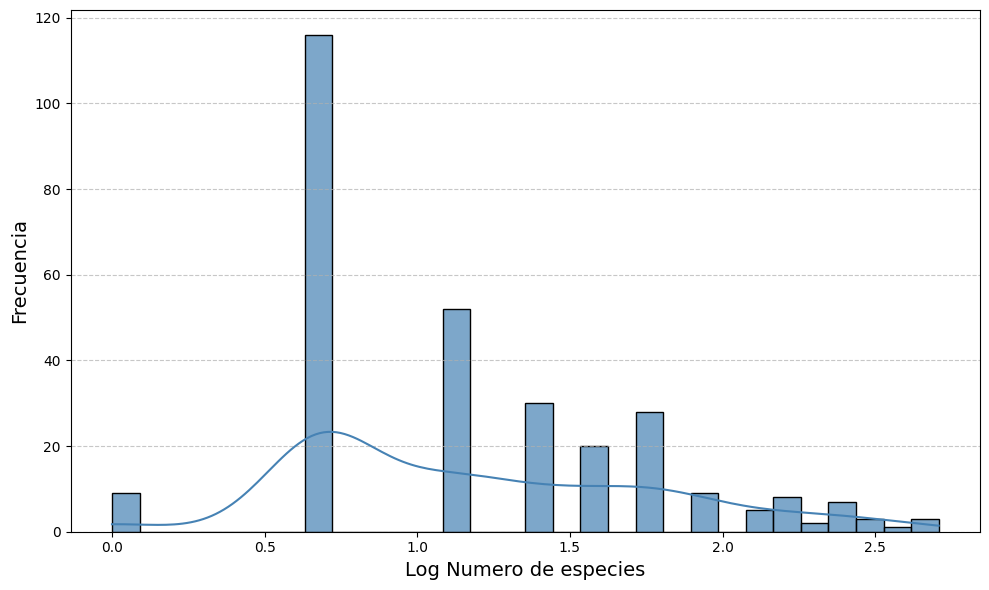

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Histograma con línea de densidad
sns.histplot(df['log_num_species'], bins=30, kde=True, color='steelblue', edgecolor='black', alpha=0.7)

# Título y etiquetas
plt.title('', fontsize=16)
plt.xlabel('Log Numero de especies', fontsize=14)
plt.ylabel('Frecuencia', fontsize=14)

# Rejilla
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Mostrar
plt.tight_layout()
plt.show()

### Para el modelo GWR requerimos coordenadas xy para las variables de entrada, por eso asiganmos como punto el centroide de las cuencas

In [6]:
# para usar las coordenadas de origen nacional
cuencas = gpd.read_file('C:/Users/danie/Documents/ESPECIALIZACION-ANALITICA/03_Analisis Geoespacial/shapes/POMCAS.gpkg')

c:\Users\danie\miniconda3\envs\GeoSpatial\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: Non-conformant content for record 1 in column Fecha_Ingr, 2021-05-06T00:00:00.0Z, successfully parsed
  return ogr_read(


In [7]:
df = df.to_crs(epsg=3857)
df.crs

<Projected CRS: EPSG:3857>
Name: WGS 84 / Pseudo-Mercator
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: World between 85.06°S and 85.06°N.
- bounds: (-180.0, -85.06, 180.0, 85.06)
Coordinate Operation:
- name: Popular Visualisation Pseudo-Mercator
- method: Popular Visualisation Pseudo Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [8]:
# Obtener centroides
# Centroides para usar como coordenadas del modelo
centroids = df.geometry.centroid
coords = np.array(list(zip(centroids.x, centroids.y)))


<Axes: >

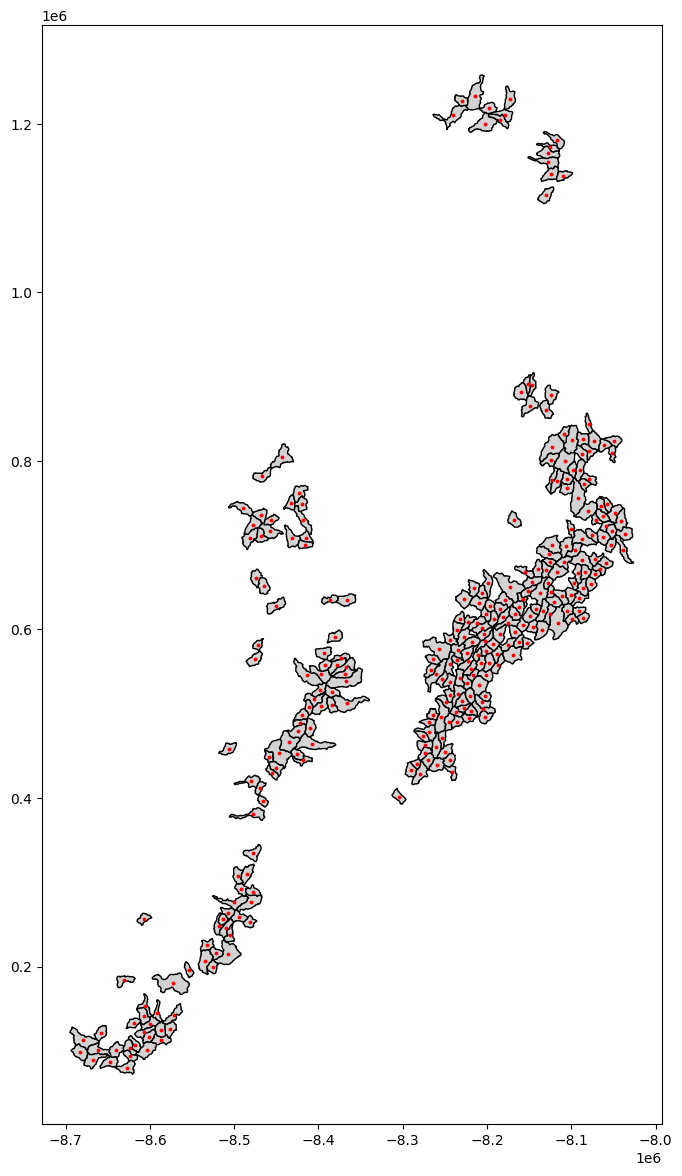

In [9]:
# Graficar los centroides
fig, ax = plt.subplots(figsize=(8,15))
df.plot(ax=ax, color='lightgrey', edgecolor='black')
centroids.plot(ax=ax, color='red', markersize=3)

In [10]:
df.columns

Index(['HYBAS_ID', 'num_species', 'num_points', 'bio1_mean', 'bio3_mean',
       'bio4_mean', 'bio7_mean', 'bio12_mean', 'bio15_mean', 'elevacion',
       'sp_density', 'num_species_std', 'w_num_species_std', 'num_points_std',
       'w_num_points_std', 'sp_density_std', 'w_sp_density_std', 'geometry',
       'log_num_species', 'log_sp_density'],
      dtype='object')

In [10]:
# Definir variables de entrada y salida
# y = df[['sp_density']].values # Con densidad
y = df[['log_num_species']].values # con numero de especies
X = df[['bio3_mean', 'bio4_mean', 'num_points', 'elevacion']].values

# estabdarizar las variables
X_std = (X - X.mean(axis=0)) / X.std(axis=0)
y = y.reshape((-1, 1))
y_std = (y - y.mean(axis=0)) / y.std(axis=0)

# run model
selector = Sel_BW(coords, y_std, X_std)
bw = selector.search(bw_min=2)
print(f"Bandwidth óptimo: {bw}")

gwr = GWR(coords, y_std, X_std, bw)
results = gwr.fit()

Bandwidth óptimo: 44.0


In [11]:
results.summary()

Model type                                                         Gaussian
Number of observations:                                                 293
Number of covariates:                                                     5

Global Regression Results
---------------------------------------------------------------------------
Residual sum of squares:                                            173.489
Log-likelihood:                                                    -338.974
AIC:                                                                687.949
AICc:                                                               690.243
BIC:                                                              -1462.401
R2:                                                                   0.408
Adj. R2:                                                              0.400

Variable                              Est.         SE  t(Est/SE)    p-value
------------------------------- ---------- ---------- ------

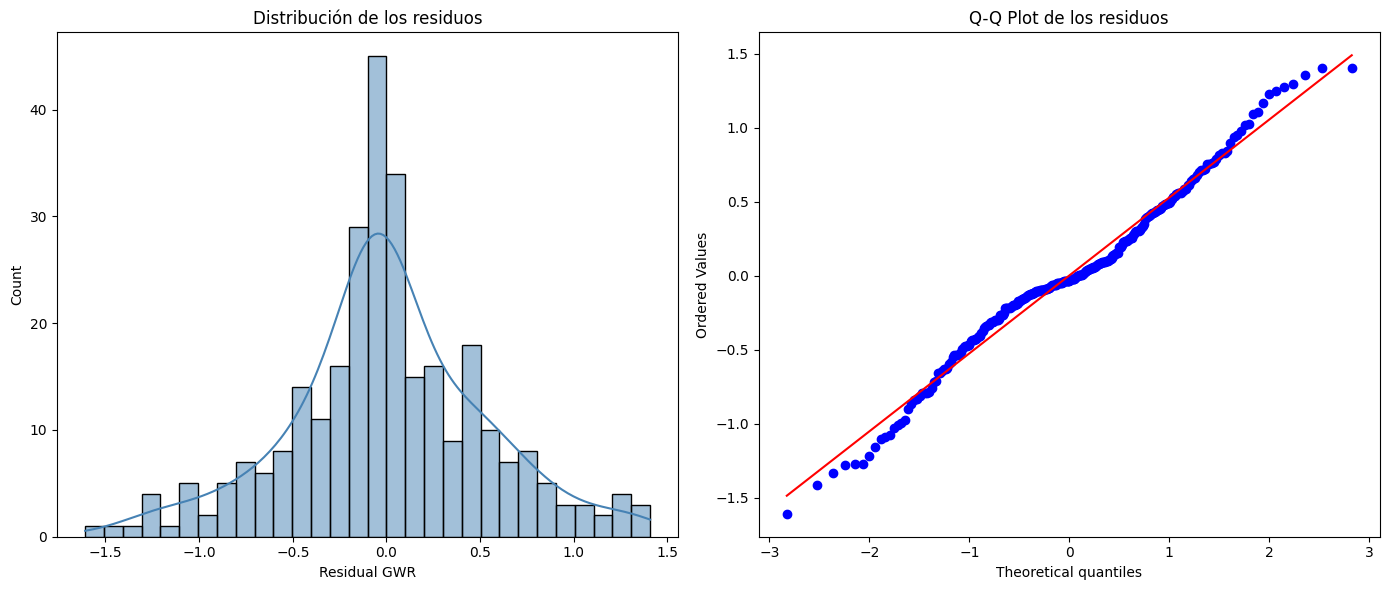

In [17]:
# evaluar los resuduales del modelo
# Agregar los residuos al DataFrame
df['residual_lgSP'] = results.resid_response

# Evaluación gráfica
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histograma con KDE
sns.histplot(df['residual_lgSP'], kde=True, ax=axes[0], bins=30, color='steelblue')
axes[0].set_title('Distribución de los residuos')
axes[0].set_xlabel('Residual GWR')

# Q-Q plot
stats.probplot(df['residual_lgSP'], dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot de los residuos')

plt.tight_layout()
plt.show()


### Verificar el indice de Moran para los residuales

In [15]:
import esda
from splot.esda import plot_moran
from libpysal.weights import DistanceBand

In [16]:
# Crear matriz DistanceBand (por ejemplo 20 km)
w_dist20km = DistanceBand.from_dataframe(df, threshold=20000, binary=False)
w_dist50km = DistanceBand.from_dataframe(df, threshold=50000, binary=False)
w_dist100km = DistanceBand.from_dataframe(df, threshold=100000, binary=False)

c:\Users\danie\miniconda3\envs\GeoSpatial\Lib\site-packages\scipy\sparse\_data.py:128: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\danie\miniconda3\envs\GeoSpatial\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 33 disconnected components.
 There are 15 islands with ids: 0, 2, 7, 15, 32, 36, 101, 121, 154, 170, 270, 271, 273, 285, 290.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\danie\miniconda3\envs\GeoSpatial\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 33 disconnected components.
 There are 15 islands with ids: 0, 2, 7, 15, 32, 36, 101, 121, 154, 170, 270, 271, 273, 285, 290.
  W.__init__(
c:\Users\danie\miniconda3\envs\GeoSpatial\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 8 disconnected components.
 There

In [17]:
print(w_dist100km.n_components)


2


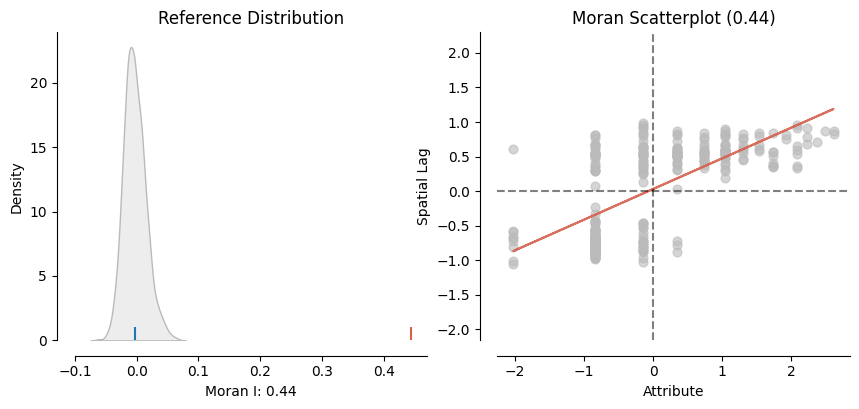

In [18]:
plot_moran(esda.Moran(df['log_num_species'], w_dist100km));

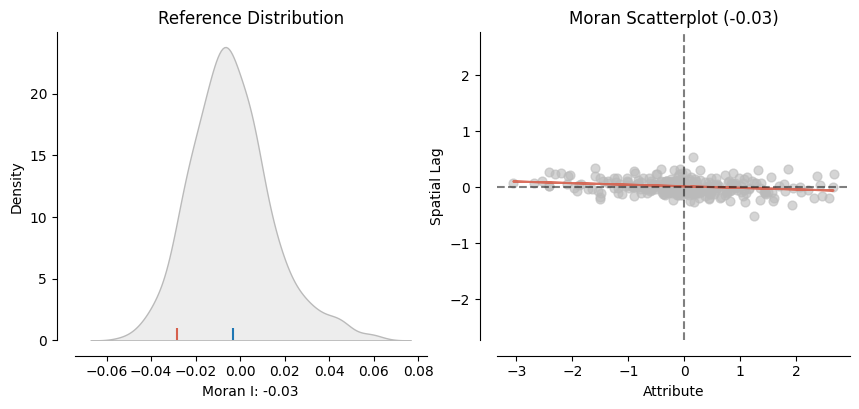

In [19]:
# Moran's I para los residuos
moran_residuals = esda.Moran(df['residual_lgSP'], w_dist100km)
plot_moran(moran_residuals);

c:\Users\danie\miniconda3\envs\GeoSpatial\Lib\site-packages\mapclassify\classifiers.py:1760: UserWarning: Not enough unique values in array to form 5 classes. Setting k to 4.
  self.bins = quantile(y, k=k)


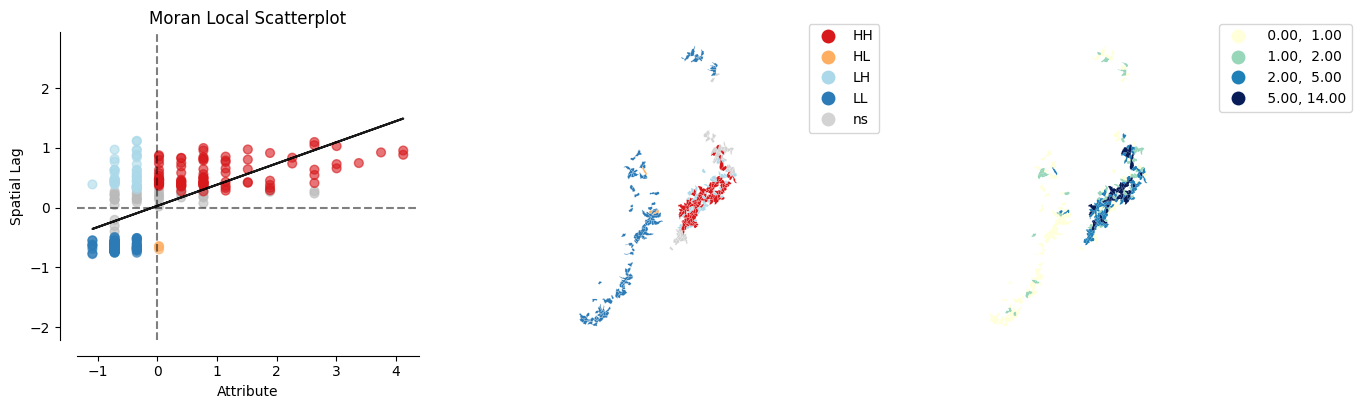

In [20]:
from splot.esda import lisa_cluster
from splot.esda import plot_local_autocorrelation

lisa = esda.Moran_Local(df['num_species'], w_dist100km)
# Break observations into significant or not
df['significant'] = lisa.p_sim < 0.05
# Store the quadrant they belong to
df['quadrant'] = lisa.q

# Grafico
plot_local_autocorrelation(lisa, df, 'num_species');

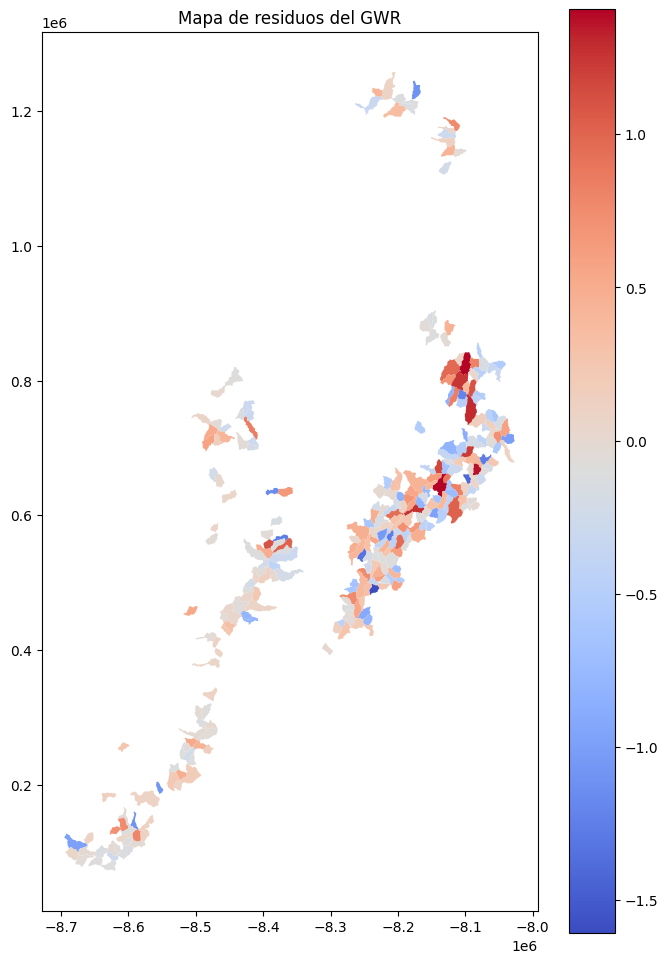

In [18]:
df.plot(column='residual_lgSP', cmap='coolwarm', legend=True, figsize=(8,12))
plt.title('Mapa de residuos del GWR')
plt.show()

In [19]:
from esda.moran import Moran
from libpysal.weights import lag_spatial
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calcular Moran
moran = Moran(df['residual_lgSP'], w_dist100km)

# 2. Calcular lag espacial
lag_resid = lag_spatial(w_dist100km, df['residual_lgSP'])

# 3. Graficar Moran Plot
plt.figure(figsize=(8,6))
sns.regplot(x=df['residual_lgSP'], y=lag_resid, ci=None, line_kws={'color':'red'})
plt.axhline(0, color='k', linestyle='--')
plt.axvline(0, color='k', linestyle='--')
plt.title(f"Moran Plot\nI = {moran.I:.3f}, p = {moran.p_sim:.3f}")
plt.xlabel("Residual")
plt.ylabel("Spatial Lag of Residual")
plt.grid(True)
plt.show()


NameError: name 'w_dist100km' is not defined

In [20]:
df["local_R2"] = results.localR2

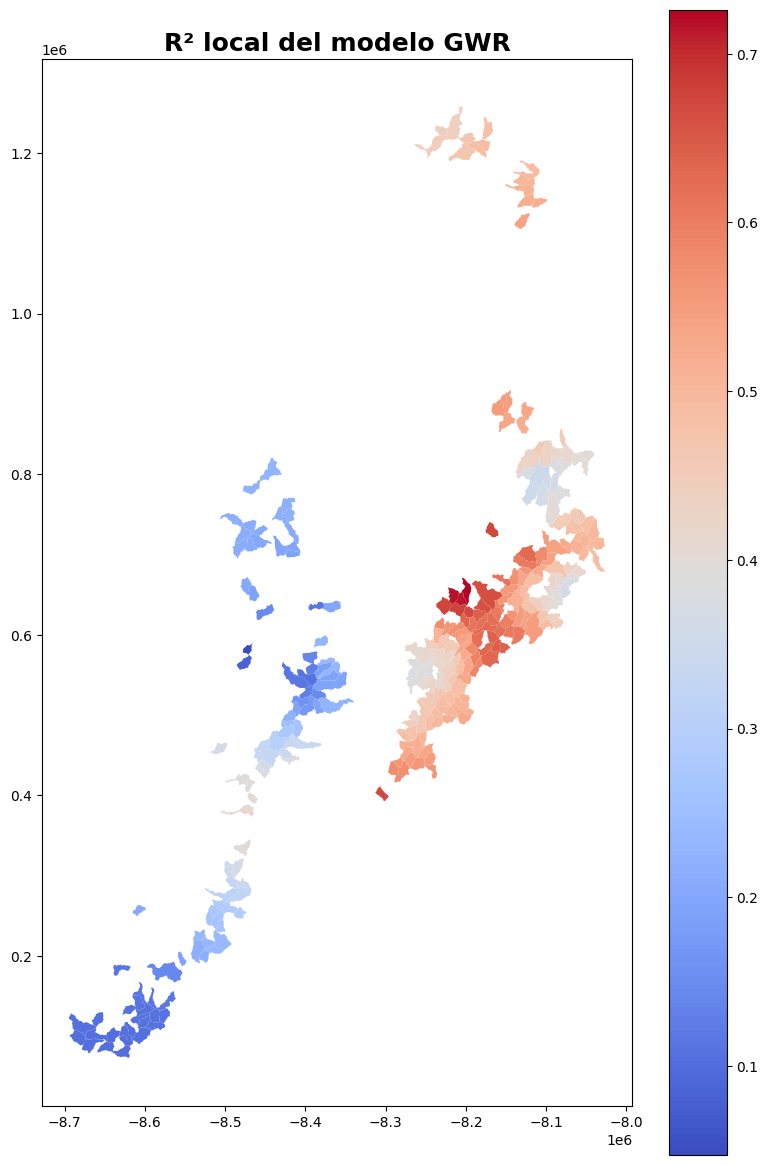

In [27]:
df.plot(column='local_R2', cmap='coolwarm', legend=True, figsize=(8,12))
plt.title('R² local del modelo GWR', fontsize=18, fontweight='bold')
ax.axis("off")
plt.tight_layout()
plt.show()

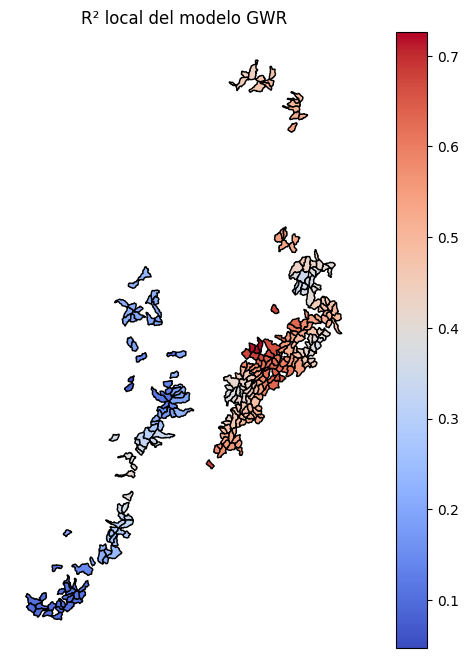

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
df.plot(column="local_R2", cmap="coolwarm", legend=True, ax=ax, edgecolor="k")
ax.set_title("R² local del modelo GWR", fontsize=18, fontweight='bold')
ax.axis("off")
plt.show()

### Ahora Graficamos los resultados del modelo GWR

In [23]:
# Mapeamos los resiltados del modelo GWR

# Asignar parámetros GWR al GeoDataFrame
df['gwr_intercept'] = results.params[:, 0]
df['gwr_bio3'] = results.params[:, 1]
df['gwr_bio4'] = results.params[:, 2]
df['gwr_numpoints'] = results.params[:, 3]
df['gwr_elev'] = results.params[:, 4]

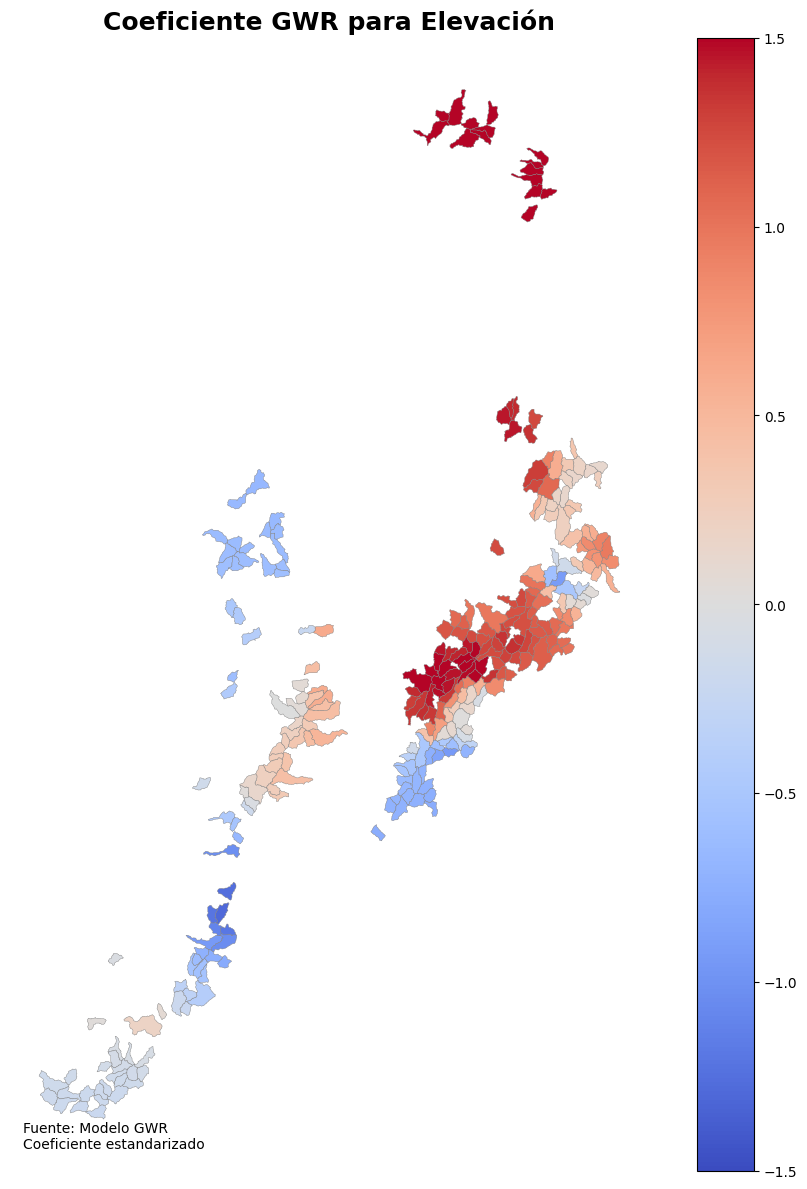

In [24]:
# Grafico mejorado
fig, ax = plt.subplots(figsize=(10, 12))

df.plot(
    column='gwr_intercept',
    ax=ax,
    cmap='coolwarm',
    edgecolor='grey',
    linewidth=0.3,
    legend=True,
    vmin=-1.5, vmax=1.5
)

ax.set_title('Coeficiente GWR para Elevación', fontsize=18, fontweight='bold')
ax.axis('off')
ax.annotate('Fuente: Modelo GWR\nCoeficiente estandarizado',
            xy=(0.02, 0.02), xycoords='axes fraction', fontsize=10)

plt.tight_layout()
plt.show()


In [25]:
results.params

array([[-0.65484029,  0.23199862,  0.16216696,  0.16219321,  0.1483765 ],
       [-0.62936262,  0.21915459,  0.19498527,  0.16304786,  0.15219897],
       [-0.62957313,  0.21903605,  0.18593775,  0.16170111,  0.15150033],
       ...,
       [-0.04230261, -0.64946882, -0.20832036,  0.15703622,  0.19149972],
       [-0.4350055 , -0.21321968,  0.06718081,  0.00616905,  0.03311658],
       [-0.60436091, -0.03510718,  0.07660867,  0.02828066,  0.09758601]],
      shape=(293, 5))

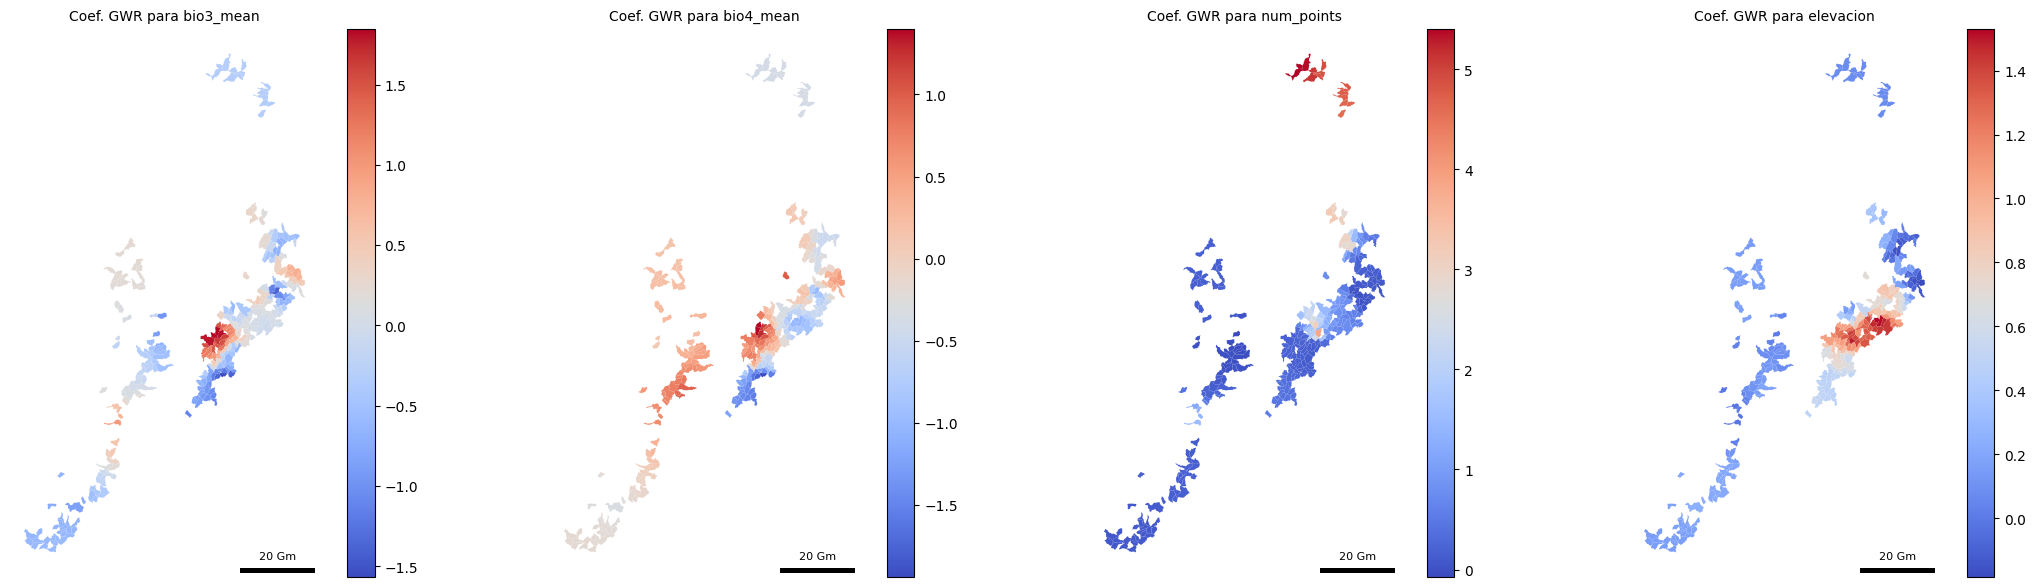

In [26]:
import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar

# Lista de tus variables predictoras (sin incluir intercepto)
param_names = ['bio3_mean', 'bio4_mean', 'num_points', 'elevacion']

# Convertir geometrías a WGS84 si aún no lo están
df_clean = df.copy()

# Obtener coeficientes locales del modelo GWR
local_params = results.params

# Crear subplots para cada coeficiente
fig, axes = plt.subplots(1, 4, figsize=(22, 6))

for i, param in enumerate(param_names):
    ax = axes[i]
    col_name = f'gwr_{param}'
    df_clean[col_name] = local_params[:, i + 1]  # +1 para evitar el intercepto
    df_clean.plot(column=col_name, ax=ax, cmap='coolwarm', legend=True)
    ax.set_title(f'Coef. GWR para {param}', fontsize=10)
    
    # Agregar barra de escala
    scalebar = ScaleBar(111319.49, "m", location='lower right', scale_loc='top', length_fraction=0.25, font_properties={"size": 8})
    ax.add_artist(scalebar)
    ax.axis('off')

plt.tight_layout()
plt.show()


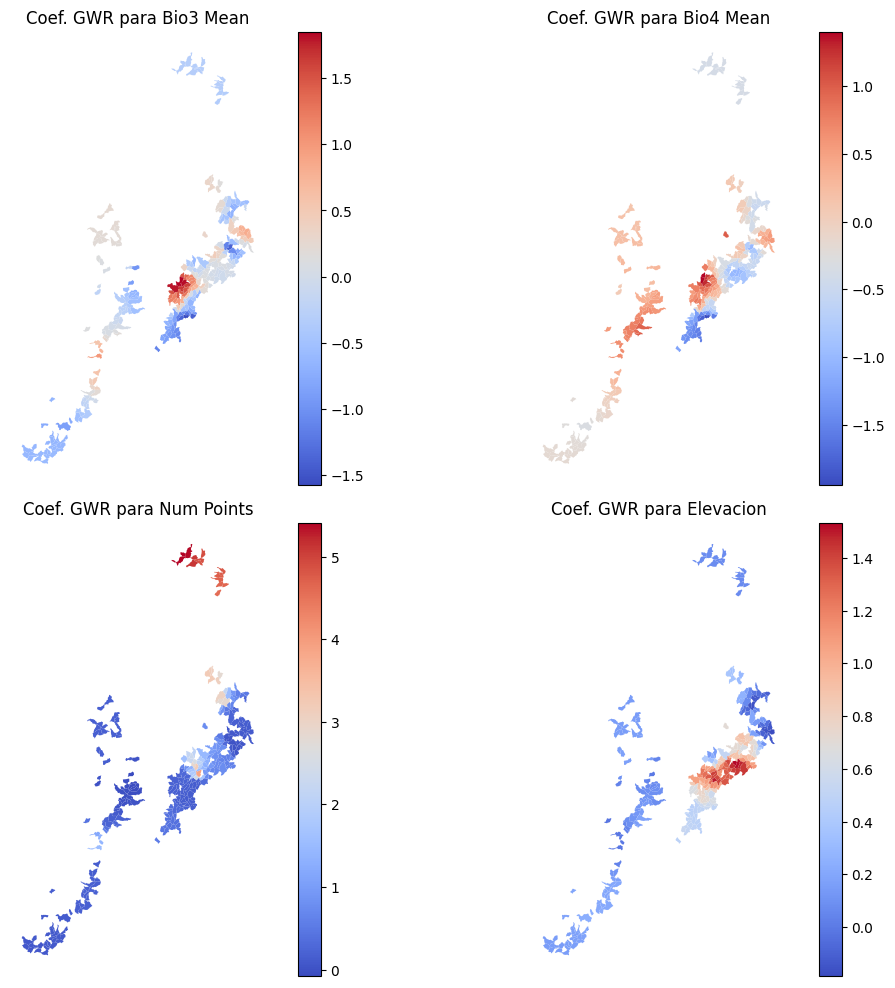

In [27]:
import matplotlib.pyplot as plt

param_names = ['bio3_mean', 'bio4_mean', 'num_points', 'elevacion']
local_params = results.params

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

df_clean = df.to_crs(epsg=4326)  # si aún no lo habías hecho

for i, param in enumerate(param_names):
    col_name = f'gwr_{param}'
    df_clean[col_name] = local_params[:, i + 1]
    df_clean.plot(column=col_name, ax=axes[i], cmap='coolwarm', legend=True)
    axes[i].set_title(f'Coef. GWR para {param.replace("_", " ").title()}')
    axes[i].axis('off')

# Ocultar el cuarto subplot vacío
axes[-1].axis('off')

plt.tight_layout()
plt.show()



### Predicción según el modelo

<Axes: >

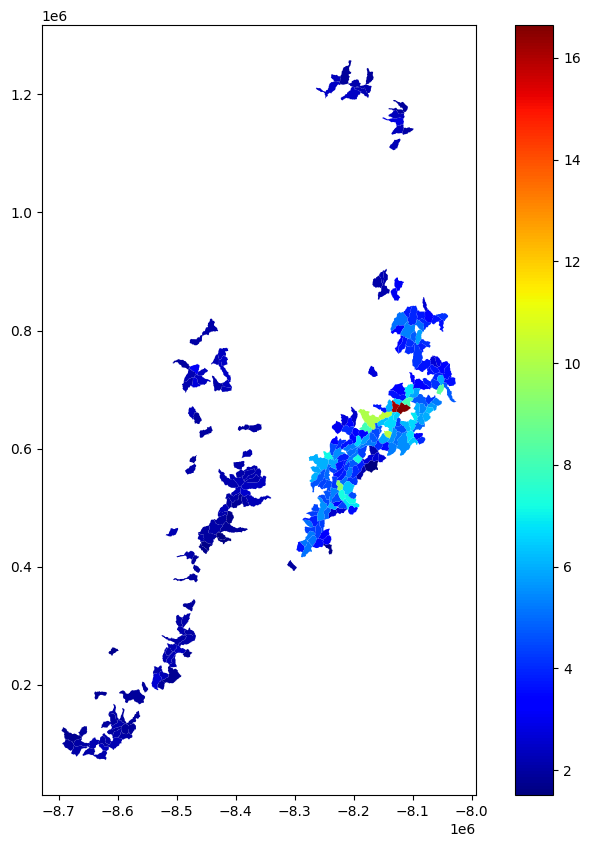

In [38]:
# volver a la escala original
y_pred_original = results.predy * y.std() + y.mean()
num_species_pred = np.exp(y_pred_original)


fig, ax = plt.subplots(figsize=(10, 10))
df["fitted"] = num_species_pred 
df.plot(column="fitted", ax=ax, cmap=plt.cm.jet, legend=True)